In [2]:
%matplotlib inline
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from PIL import Image
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
plt.rcParams['text.usetex'] = True
plt.rcParams.update(plt.rcParamsDefault)

from IPython.display import Image 

def plot(x, y, xlabel, ylabel, legend, color):
    plt.plot(x,y,lw=3,label = legend, color=color)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(frameon=False)
    # xlim(3.6,5.5)
    # plt.yscale('log')

    
#fonction pour tracer les courbes linéaire et semilog subplot 2x1- adapter les legendes et les entrées en fonction de votre mesures
def plot1(vd, Id, label, color):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.suptitle('caractéristique d`une diode')
    ax1.plot(vd, Id,lw=3,label = label, color=color)
    ax1.set_xlabel("vd (V)")
    ax1.set_ylabel("Id (mA)")
    ax1.grid()
    ax2.semilogy(vd, Id,lw=3,label = label, color=color)
    ax2.set_xlabel("vd (V)")
    ax2.set_ylabel("Id (mA)")
    ax2.grid()
    plt.legend(frameon=False)
    plt.subplots_adjust(wspace=0.4,hspace=0.4)
    
# #fonction pour tracer les courbes subplot 3x1- adapter les legendes et les entrées en fonction de votre mesures
# def plot2(x, y, label, color):
#     fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
#     fig.suptitle('caractéristique d`une diode')
#     ax1.plot(vd, Id,lw=3,label = label, color=color)
#     ax1.set_xlabel("vd (V)")
#     ax1.set_ylabel("Id (mA)")
#     ax1.grid()
#     ax2.plot(vd, Id,lw=3,label = label, color=color)
#     ax2.set_xlabel("vd (V)")
#     ax2.set_ylabel("Id (mA)")
#     ax2.grid()
#     plt.legend(frameon=False)
#     plt.subplots_adjust(wspace=0.4,hspace=0.4)

#Sauvegarder vos fichiers simulations et Jupyter dans un chemin
path = r"H:\Mon Drive\2025-2026_polytech_sorbonne\S6\UE-Electronique\Composants_et_circuit_microelectrique\TP\Sujet_TP_YEK"

 <center><b><font size="30">ÉTUDE DES COMPOSANTS ET CIRCUITS ANALOGIQUES</b></center>

***
**Durée** : 6h30 de manipulations et de simulations  
**Traitement** : 30 min mise en forme et interprétation des résultats  
**Configuration** : Monome en salle électronique sur machine Polytech - les PC personnels ne sont pas autorisées par les admins.  
**Logiciel** : LTSpice et codes d'acquisition en python pour SMU 2450   
**Matériels** : sourcemetre : [SMU 2450](https://download.tek.com/manual/2450-900-01E_Aug_2019_User.pdf), Labdec, diodes : [1N4003](https://www.onlinecomponents.com/en/datasheet/1n4003-12004935/), [Zener 5V1 1N4733ATR](https://www.farnell.com/datasheets/1482758.pdf), série de résistances (1 MΩ requis) et capacités (47 μF), CMOS : [CD4007UBE](https://www.win-source.net/datasheet/90281/CD4007UBE.pdf), BJT (NPN) : [CA3046](https://www.mouser.com/catalog/specsheets/intersil_fn341.pdf)  
**Évaluation** : les CR individuels seront relevés en fin de séance 2 - Les encadrants poseront des questions pendant les séances. Les plagiats (relevés, photos, commentaires) seront traités comme une fraude par l'école. 
***

**INTRODUCTION**  
Ce TP est constitué de 6 parties dans lesquelles vous étudierez tant en simulations qu'en mesures différents composants (diode, BJT, MOS) et circuits de bases notamment amplificateurs. Ces manipulations simples vous permettront d'observer les caractéristiques des composants et circuits et la mesure de leurs grandeurs caractéristiques. Afin de d'optimiser votre temps de mesure, il est indispensable que vous ayez préparé les etudes theoriques et les simulations de vos circuits. 
Jupyter notebook supporte Latex et l'ensemble des courbes devra être inséré ici. Des methodes pour les tracés sont indiquées ci-dessus. Il vous suffit d'adapter selon la représentation souhaitée.  
**TP1 A à D**   
bonus pour ceux qui auront su modifier le codes SMU pour mesurer $V_o$ vs. $V_I$ dans A2  
bonus pour les mesures sur PMOs et BJT  
**TP2 suite**   
bonus pour ceux qui auront comparés CE (BJT) et CS (MOS)

**Mesures SMU codes python**  
Il n'y a que 6 SMU. 1 SMU peut forcer une tension et mesurer un courant et reciproquement. La caractéristique I-V d'une diode, vous utiliserez un SMU avec le code 2450_data.py que vous lancerez via une commande sous VScode d'anaconda sur les machines de salle TP (le lancer sous powershell via la commande *CODE* et assurez vous d'etre dans l'environnement *base*). Pour afficher en temps réel les mesures, vous lancerez en parallèle dans une seconde fenetre de commande le code 2450_liveplot.py.  
Pour une mesure I-V de transistor, vous lancerez le code measurement_MOS.py en ayant pris soin de paramétrer le code instrument_setting.py. Ici le tracé en temps réel est déja intégré par contre vous devrez choisir quelle type de caractéristique transfert ou sortie mesurer dans le code.

# **A - CARACTÉRISTIQUE DE TRANSFERT D'UNE DIODE**  
**Objectifs**: analyser, simuler et mesurer la caractéristique de transfert d'une diode  
## **A1 - Simulation**:  
On considère le circuit de la [figure 1](#fig1)
simuler ce circuit en variant $V_{I}$ de -1 V à +3 V avec un pas de 0.1 V dans un premier temps puis adapter la plage. Exporter le fichier de calculs .txt de LTspice et appeler le dans la dataframe data 
- Tracer $i_D$ vs. $V_I$, $V_o$ vs. $V_I$ et $i_D$ vs. $V_D$ (échelle linéaire et/ou semilog). Commentez.

Index(['Vi', 'V(vi)', 'V(vo)', 'I(D1)'], dtype='str')


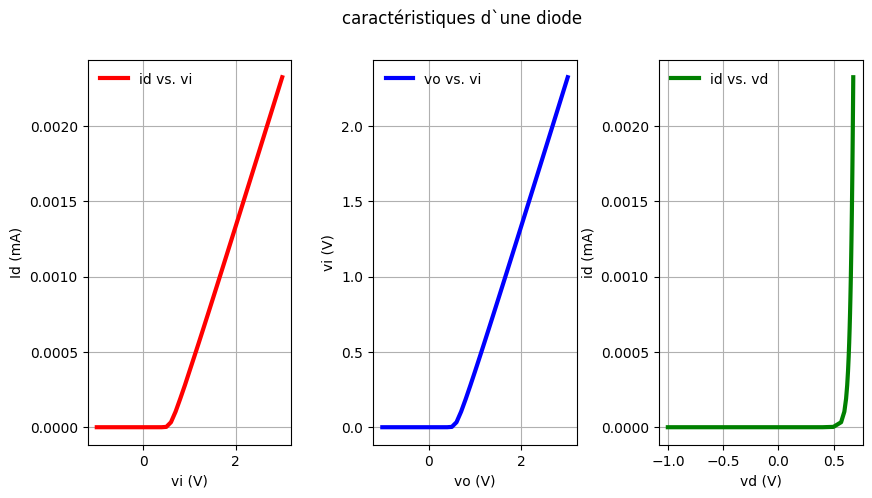

In [ ]:
#exporter vos simulations en .txt et tracer les en subplot dans cette cellule
#adapter les labels des dataframes en fonctions de v
data = pd.read_csv(path+"\\Simulation\\Simu_A\\Simu_A.txt",  delimiter = "\t")
# print(data)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,5))

print(data.columns)
fig.suptitle('caractéristiques d`une diode')
ax1.plot(data["V(vi)"], data["I(D1)"], lw=3,label = "id vs. vi", color="red")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("Id (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(data["V(vi)"], data["V(vo)"], lw=3,label = "vo vs. vi", color="blue")
ax2.set_xlabel("vo (V)")
ax2.set_ylabel("vi (V)")
ax2.grid()
ax2.legend(frameon=False)
# ax3.semilogy(data["V(vi)"]-data["V(vo)"], data["I(1n4003gp)"], lw=3,label = "id .vs vd", color="green")
ax3.plot(data["V(vi)"]-data["V(vo)"], data["I(D1)"], lw=3,label = "id vs. vd", color="green")
ax3.set_xlabel("vd (V)")
ax3.set_ylabel("id (mA)")
ax3.grid()
ax3.legend(frameon=False)
# fig.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

- Remplacez l'alimentation dc par un GBF et paramétrez le pour déterminer la résistance dynamique $r_d$ de la diode. Montrer que $r_d$ est égale en première approximation à $\frac{26 mV}{i_D}$. 

$r_d$ pour 3 pts de la caracteristique I-V: se placer sur un point de polarisation et superposez un signal ac - extraire $$\frac{\partial i}{\partial v}$$. 
Le facteur d'idéalité $n = 1$ pour la diode 1N4003. $$r_d = \frac{26mV}{i_d}$$


texte réponse

$$\frac{26mV}{i_d}$$.


<img src="./PNG_circuits/lab41_diode.png" width="500" style="display:block; margin:auto;">
<p style="text-align:center"><strong>Fig. 1</strong>: diode</p>


## **A2- Mesures**:  
Assemblez le circuit sur une labdec et variez l'alimentation dc $V_I$ sur une plage et avec un pas adéquats. Pour chaque point, mesurez la tension de sortie $V_o$ au multimètre, et relevez le courant $i_D$ débité par l'alimentation.  
- Tracer $i_D$ vs. $V_I$, $V_o$ vs. $V_I$.  
- Tracer $i_D$ vs. $V_D$ (échelle linéaire et semilog), déterminer le seuil  
- Pour mesurer $r_d$, injectez 100 mVpp au GBF autour d'un pt de polarisation Q en prendre 2 ou 3 judicieusement choisis (GBF (ac) + offset (Q))
- À la suite des mesures manuelles, demandez une démo de mesure automatique par SMU à l'encadrant

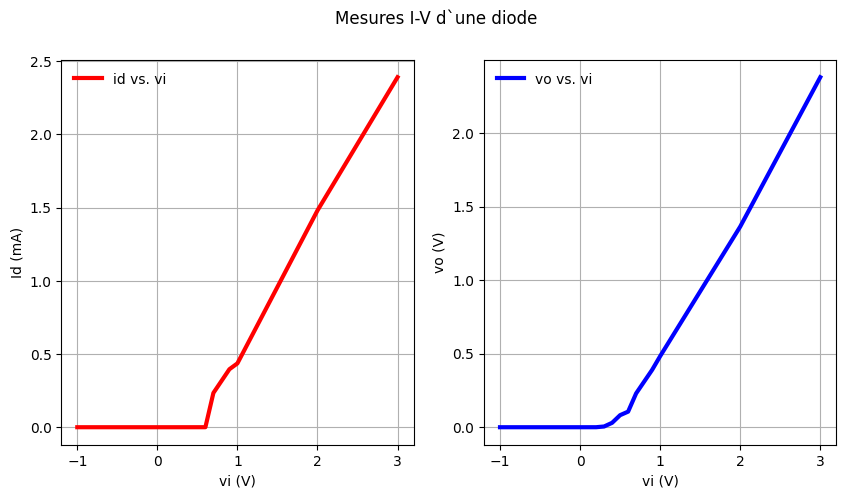

In [9]:
#TP CCM 
# adapter les variations de tensions - celles mentionnées ne sont qu`indicatives.
#A-Diode
vi =  [-1,0 ,0.2,	0.3,	0.4,	0.5,	0.6,	0.7,	0.8,	0.9,1,2,3]  # en V
vo = [0,0,0.000081,	0.005,	0.03,	0.082,	0.106,	0.23,	0.31,	0.39,	0.483,	1.364,	2.38] # en mA
vd = np.subtract(vi, vo)
Id = [0	,0,	0.00000011,	0.0000015,	0.000031, 0.000083,	0.000107,	0.234,	0.315,	0.396,	0.436,	1.48,	2.39] # en A
# plot(vd, Id, 'Id vs.vout', "mediumseagreen")
# plot(data["v1"], data["I(1n4003gp)"]/1e-3, "fit", "blue")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('Mesures I-V d`une diode')
ax1.plot(vi, Id, lw=3,label = "id vs. vi", color="red")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("Id (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(vi, vo, lw=3,label = "vo vs. vi", color="blue")
ax2.set_xlabel("vi (V)")
ax2.set_ylabel("vo (V)")
ax2.grid()
ax2.legend(frameon=False)
plt.show()


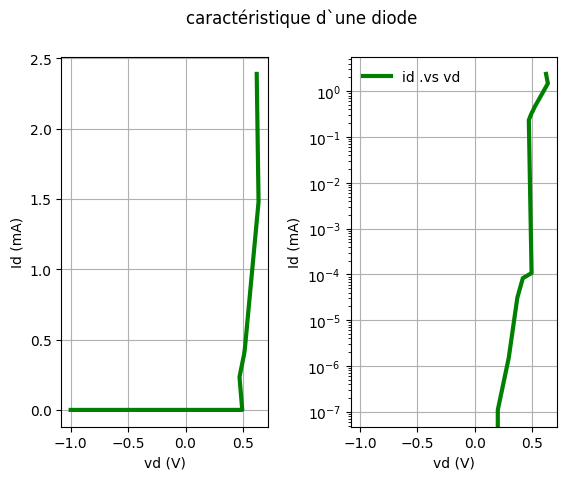

In [10]:
plot1(vd, Id, "id .vs vd", "green")
plt.show()


## **A3 - Traitement post-mesures**:  
- Déterminez la résistance statique $r_f$ de la diode pour 3 courants caractéristiques. Commentez.<br>
- Superposez vos mesures aux simulations (exportez le fichier .txt de LTspice et appelez le dans la dataframe data). <br>
- Constatez vous une différence majeure avec les simulations? (attention au modèle choisi)  

In [11]:
#Mesure de rd
# injecter 100 mVpp au GBF autour d`un pt de polarisation en prendre 2 ou 3 (GBF + offset)
#rd = Vrms/Irms
#pts de polarisation [0.6V, 0.7V, 0.8V]
Vpolarisation =[0.6, 0.7, 0.8]
Vrms = 50e-3/np.sqrt(2)
Idrms = [0.008,0.01,0.012]   # composante ac mesurée au milliamperementre
rd = Vrms/Idrms
print("points de polarisation (V) : ", Vpolarisation)
print("rd (en ohms)= ", rd)

points de polarisation (V) :  [0.6, 0.7, 0.8]
rd (en ohms)=  [4.41941738 3.53553391 2.94627825]


## **Commentaires**

In [ ]:
#mettez vos résultats ici avec les interpretations#

# **B - CIRCUITS Á DIODES**  
**Objectifs**: analyser, simuler et mesurer différents circuits á diodes e.g. détecteur de pic, ecrêteurs et limiteurs, doubleurs.  
## **B1 - Simulation**: 
On considère le circuit de la [figure 2](#fig2)
- Simulez chaque circuit avec les paramètres indiqués. <br> 
- Pour chaque simulation, tracez $V_{I}$ et $V_{o}$ en fonction du temps.

(a) - limiteur: R=1 ko, diode 1N4003, $V_{I}$ est un sinus de 5 V$_{pk-pk}$ sans offset, f=100 Hz<br>
(b) - limiteur Zener: R=1 ko, diode 1N4733A, $V_{I}$ est un sinus de 15 V$_{pk-pk}$ sans offset, f=100 Hz<br>
(c) - écreteur à capacité: $R_L$=10 ko, C=47 $\mu$F, diode 1N4003, $V_{I}$ est un carré de 2 V$_{pk-pk}$ sans offset, f=100 Hz<br>
(d) - doubleur de tension:  $R_L$=100 ko en charge, C1=C2=47 $\mu$F, diode 1N4003, $V_{I}$ est un sinus de 5 V$_{pk-pk}$ sans offset, f=100 Hz<br>

<img src="./PNG_circuits/lab43_circuits_diodes.png"
     width="500"
     style="display:block; margin:auto;">
<p style="text-align:center"><strong>Fig. 2</strong>: circuits à diodes</p>

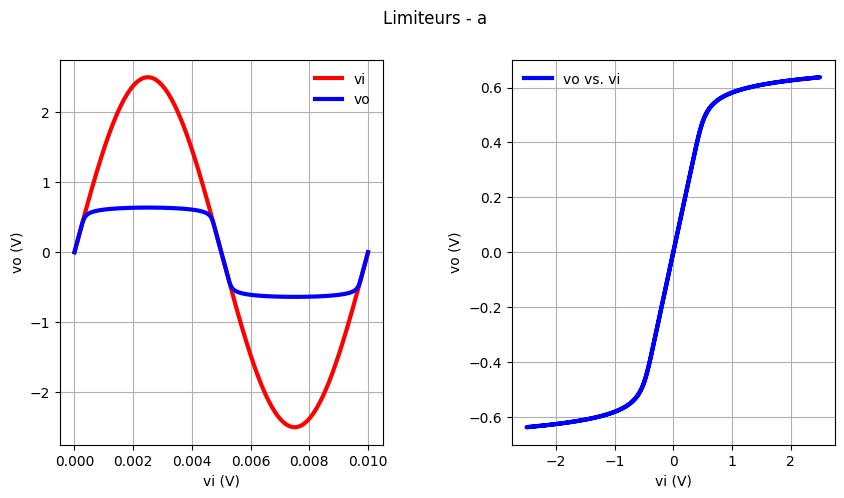

In [12]:
#exporter vos simulations en .txt et tracer les en subplot dans cette cellule
a = pd.read_csv(path+'\\Simulation\\Simu_B\\Simu_B_a.txt',  delimiter = "\t")
b = pd.read_csv(path+'\\Simulation\\Simu_B_b\\Simu_B_b.txt',  delimiter = "\t")
c = pd.read_csv(path+'\\Simulation\\Simu_B\\Simu_B_c.txt',  delimiter = "\t")
d = pd.read_csv(path+'\\Simulation\\Simu_B\\Simu_B_d.txt',  delimiter = "\t")

# limiteur - a
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('Limiteurs - a')
ax1.plot(a["time"], a["V(vi)"],  lw=3,label = "vi", color="red")
ax1.plot(a["time"], a["V(vo)"],  lw=3,label = "vo", color="blue")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("vo (V)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(a["V(vi)"], a["V(vo)"],  lw=3,label = "vo vs. vi", color="blue")
ax2.set_xlabel("vi (V)")
ax2.set_ylabel("vo (V)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

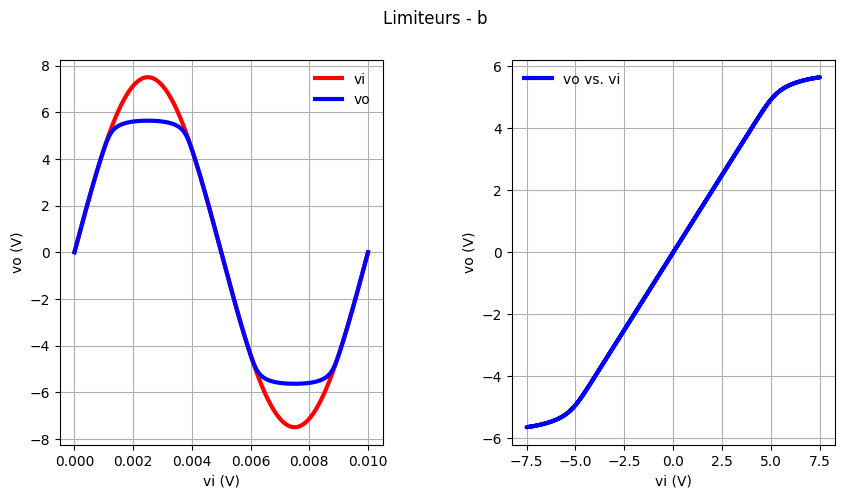

In [13]:
# limiteur - b
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('Limiteurs - b')
ax1.plot(b["time"], b["V(vi)"],  lw=3,label = "vi", color="red")
ax1.plot(b["time"], b["V(vo)"],  lw=3,label = "vo", color="blue")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("vo (V)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(b["V(vi)"], b["V(vo)"],  lw=3,label = "vo vs. vi", color="blue")
ax2.set_xlabel("vi (V)")
ax2.set_ylabel("vo (V)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

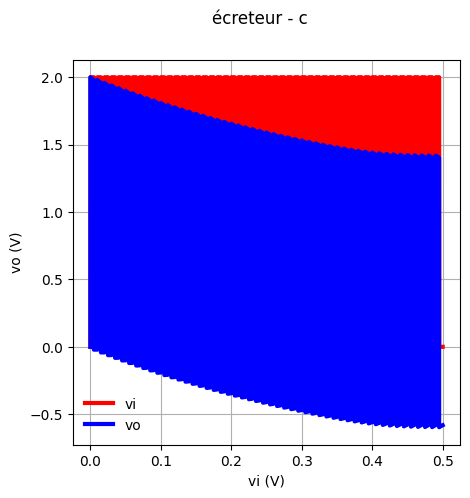

In [14]:
# ecreteur - c
fig, (ax1) = plt.subplots(1, 1, figsize=(5,5))
fig.suptitle('écreteur - c')
ax1.plot(c["time"], c["V(vi)"],  lw=3,label = "vi", color="red")
ax1.plot(c["time"], c["V(vo)"],  lw=3,label = "vo", color="blue")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("vo (V)")
ax1.grid()
ax1.legend(frameon=False)
plt.show()

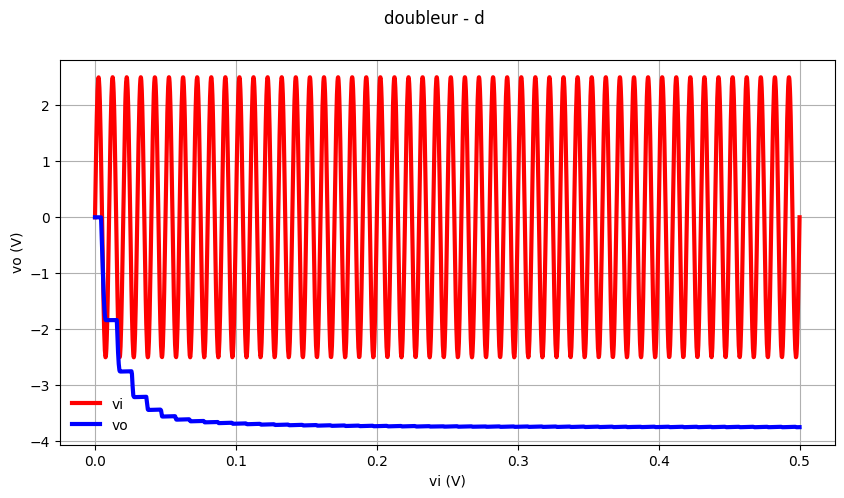

In [15]:
# doubleur - d
fig, (ax1) = plt.subplots(1, 1, figsize=(10,5))
fig.suptitle('doubleur - d')
ax1.plot(d["time"], d["V(vi)"],  lw=3,label = "vi", color="red")
ax1.plot(d["time"], d["V(vo)"],  lw=3,label = "vo", color="blue")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("vo (V)")
ax1.grid()
ax1.legend(frameon=False)
plt.show()

## **B2 - Mesures**: 
Assemblez chacun des circuits et appliquez le signal en entrée spécifié dans la partie description ci-dessus en utilisant un GBF. Mesurez la sortie avec un oscilloscope.<br>
- Pour les circuits (a - c) relever les tensions minimales et maximales
- Pour les circuits limiteurs, representez en mode X-Y la tension $V_o$ vs. $V_I$

## **B3 - Traitement post mesures**: 
Commentez les fonctions réalisées et comparez avec vos simulations. <br>
- Est il possible de changer le circuit limiteur pour limiter entre +/- 1.4 V<br>
- Est il possible d‘obtenir un ecrêtage négative <br>
- Est il possible de modifier le doubleur de tension pour obtenir une tension positive

#coller ici les screenshots de l`oscillo
# Limiteur diodes - a
<img src="./Photo/B2_Mesures_circuits_a.jpg" width="250" style="display:block; margin:auto;">
<img src="./Photo/B2_Mesures_circuits_a_bis.jpg" width="250" style="display:block; margin:auto;">

# Limiteur diodes - b
<img src="./Photo/B2_Mesures_circuits_b.jpg" width="250" style="display:block; margin:auto;">
<img src="./Photo/B2_Mesures_circuits_b_bis.jpg" width="250" style="display:block; margin:auto;">

# Limiteur diodes - c
<img src="./Photo/B2_Mesures_circuits_c.jpg" width="250" style="display:block; margin:auto;">

# doubleur diodes - d  ajouter RL dans le texte
<img src="./Photo/B2_Mesures_circuits_d.jpg" width="250" style="display:block; margin:auto;">


## **Commentaires**

In [22]:
#mettez vos résultats ici avec les interpretations#

# **C - CARACTÉRISTIQUES DE TRANSFERT D‘UN TRANSISTOR NMOS**  
**Objectifs**: Simuler et mesurer les paramétres d'un transistor en fonction du courant de drain vs. la tension grille-source et source-drain. Extraire les paramètres : $k_n$, $V_{tn}$ et eventuellement $\lambda_n$  
**NB**: observez bien le brochage des transistors notamment le substrat (B) pour les NMOS et PMOS - choisissez judicieusement le NMOS à etudier. Vous prendrez ici un NMOS dont le substrat est connecté à la source.
## **C1 - Simulation**:  
On considère le circuit de la [figure 3](#fig3). On prendra SMU1 pour la tension de grille  $V_{GS}$ et SMU2 pour la tension de drain  $V_{DS}$ et la mesure du courant de drain  $I_{DS}$ - attention aux IP des SMU que vous devez introduire dans le code. Polarisez à l'aide des alimentations dc et de résistances de polarisation le circuit et :
- Tracez $I_D$ vs. $V_{GS}$ : maintenir $V_{DS}$ constant á 5 V et balayez la tension de grille de 0 á 5 V par pas de 0.1 V. Déterminez la tension de seuil de $V_{GS}$ i.e $V_{tn}$ pour laquelle le courant augmente
- Tracez $I_D$ vs. $V_{DS}$ : pour 3 valeurs de $V_{GS}$ (2.5, 3 et 3.5 V), balayez la tension de drain de 0 á 5 V par pas de 0.1 V. Quelles informations êtes vous susceptibles d'extraire de ces caractéristiques de sortie.

<!-- <img src="attachment:fe9cc609-77ba-472c-bb94-c17cab0519f6.png" width="300" text-align="Figure 3" style="margin-left:auto; margin-right:auto" id="fig3">
<p style="text-align:center"><strong>Fig. 3</strong>: Transistor MOS</p> -->


<img src="./PNG_circuits/lab51_NMOSIV.png" width="500" style="display:block; margin:auto;">
<p style="text-align:center"><strong>Fig. 3</strong>: Transistor MOS</p>


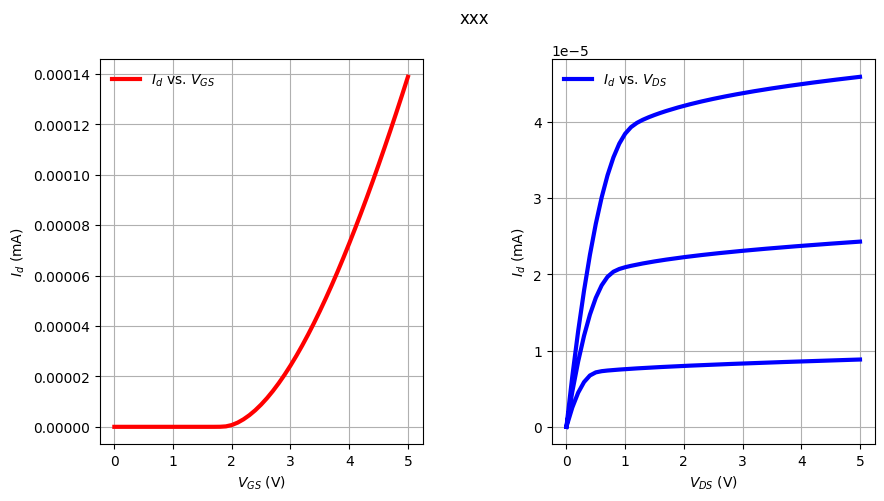

In [20]:
#exporter vos simulations en .txt et tracer les en subplot dans cette cellule
a = pd.read_csv(path+'\\Simulation\\Simu_C\\Simu_C_cas_1.txt',  delimiter = "\t")
b = pd.read_csv(path+'\\Simulation\\Simu_C\\Simu_C_cas_2.txt',  delimiter = "\t")
# NMOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('xxx')
ax1.plot(a["V(vgs)"], a["Id(M1)"],  lw=3,label = "$I_d$ vs. $V_{GS}$", color="red")
ax1.set_xlabel("$V_{GS}$ (V)")
ax1.set_ylabel("$I_d$ (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(b["V(vds)"], b["Id(M1)"],  lw=3,label = "$I_d$ vs. $V_{DS}$", color="blue")
ax2.set_xlabel("$V_{DS}$ (V)")
ax2.set_ylabel("$I_d$ (mA)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

Vtn_theorique = : 1.38 V
Vtn modele ltspice = : 1.40 V
Ecart relatif entre valeur modele ltspice et calculer = : 1.49 %
Kn : 21.19 µA/V^2
Lambda corrigé : 0.0265 1/V
Va : 37.72 V


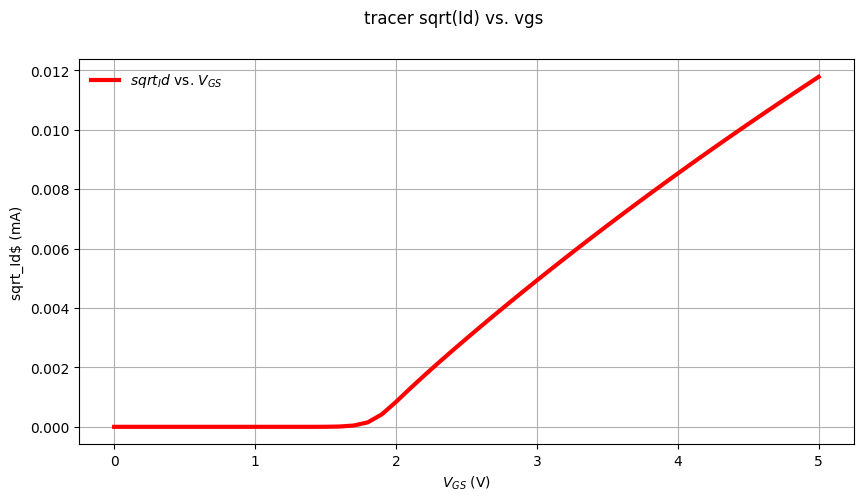

In [104]:
#Traitement des simulations -  extraire k_n, V_tn et 1/Va = lambda
# print(a)
# Determiner Vt et kn prendre les données pour id vs. vgs  pour 1 Vds assurant la saturation  

# Calcule de Vtn_composant
Vtn_modele_spice = 1.4 # Donner dans la description du nmos dans Ltspice 

point_courbe_1 = a.iloc[40] # Prenons les points pour Vgs = 4V
point_courbe_2 = a.iloc[50] # Prenons les points pour Vgs = 5V

# Calculons la pente de la droite de Id vs Vgs
pente_droite_id_vs_vgs = (np.sqrt(np.abs(point_courbe_2["Id(M1)"])) - np.sqrt(np.abs(point_courbe_1["Id(M1)"]))) / (point_courbe_2["V(vgs)"] - point_courbe_1["V(vgs)"])
# Calculons la valeur de Vtn avec la formule : 
# Vtn = Vgs - RACINE(Id) / pente de la droite
Vtn_theorique = point_courbe_1["V(vgs)"] - (np.sqrt(point_courbe_1["Id(M1)"]) / pente_droite_id_vs_vgs)

ecart_vt = ((Vtn_modele_spice - Vtn_theorique)/Vtn_theorique)*100
print(f"Vtn_theorique = : {Vtn_theorique:.2f} V")
print(f"Vtn modele ltspice = : {Vtn_modele_spice:.2f} V")
print(f"Ecart relatif entre valeur modele ltspice et calculer = : {ecart_vt:.2f} %")

ligne_50 = a.iloc[50] # Je récuper la 50ème ligne qui contienne toutes mes donnée en régime de saturetion

# Calcule de Kn
kn = 2*ligne_50["Id(M1)"] / (ligne_50["V(vgs)"] - Vtn_theorique)**2
print(f"Kn : {kn*1e6:.2f} µA/V^2")

# Calcul de lambda
# Prends deux points bien en saturation 
# on prends les valeurs de Vds = 3V et Vds = 5V lorsque Vgs = 3.5V
point_courbe_1 = b[b["V(vds)"] == 3.0].iloc[-1]
point_courbe_2 = b[b["V(vds)"] == 5.0].iloc[-1]

id1, vds1 = point_courbe_1["Id(M1)"], point_courbe_1["V(vds)"]
id2, vds2 = point_courbe_2["Id(M1)"], point_courbe_2["V(vds)"]

# Applique la formule dérivée du rapport
lanbda = (id2 - id1) / (id1 * vds2 - id2 * vds1)
print(f"Lambda corrigé : {lanbda:.4f} 1/V")
Va = 1/lanbda

print(f"Va : {Va:.2f} V")


#tracer sqrt(Id) vs. vgs
sqrt_Id= np.sqrt(a["Id(M1)"])
# print(sqrt_Id)

fig, (ax1) = plt.subplots(1,figsize=(10,5))
fig.suptitle('tracer sqrt(Id) vs. vgs')
ax1.plot(a["V(vgs)"], sqrt_Id,  lw=3,label = "$sqrt_Id$ vs. $V_{GS}$", color="red")
ax1.set_xlabel("$V_{GS}$ (V)")
ax1.set_ylabel("sqrt_Id$ (mA)")
ax1.grid()
ax1.legend(frameon=False)
plt.show()




## **C2 - Mesures**: 
Assemblez le circuit de la [figure 3](#fig3) avec les 2 alimentations dc connectées à la grille et au drain puis tracer:
- $I_D$ vs. $V_{GS}$ : maintenir  $V_{DS}$ constant á 5 V et balayez la tension de grille de 0 á 3.5 V par pas de 0.25 V (on réduit le nombre de points par rapport aux simulations) et mesurez le courant de drain débité par l‘alimentation. Identifiez la tension de seuil.
- $I_D$ vs. $V_{DS}$ : pour 3 valeurs de $V_{GS}$ (2.5, 3 et 3.5 V), balayez la tension de drain de 0 á 3.5 V par pas de 0.5 V et mesurez $I_D$.

In [ ]:
#IV NNOS
# mesures Id vs Vgs
Vds = 5
Vgs =  [vos mesures]  # en V
Id =   [vos mesures] # en V
# mesures Id vs Vds
Vgs_1 = xx
Vgs_2 = xx
Vgs_3 = xx
Vgs_4 = xx

Vds_1 =  [vos mesures]  # en V
Id_1 =   [vos mesures] # en V
Vds_2 =  [vos mesures]  # en V
Id_2 =   [vos mesures] # en V
Vds_3 =  [vos mesures]  # en V
Id_3 =   [vos mesures] # en V
Vds_4 =  [vos mesures]  # en V
Id_4 =   [vos mesures] # en V
#courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('Caractéristiques I-V d`un NMOS CD4007')
ax1.plot(Vgs, Id,  lw=3,label = "$I_d$ vs. $V_{GS}$ @ $V_{DS}$ = 5 V", color="red")
ax1.set_xlabel("$V_{GS}$ (V)")
ax1.set_ylabel("$I_d$ (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(Vds_1,Id_1,lw=3,label = '$V_{GS}$ = 1 V', color="black")
ax2.plot(Vds_2,Id_2,lw=3,label = '$V_{GS}$ = 1.5 V', color="red")
ax2.plot(Vds_3,Id_3,lw=3,label = '$V_{GS}$ = 1.7 V', color="blue")
ax2.plot(Vds_4,Id_4,lw=3,label = '$V_{GS}$ = 2 V', color="green")
ax2.set_xlabel("$V_{DS}$ (V)")
ax2.set_ylabel("$I_d$ (mA)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)

          Timestamp  Gate_Voltage  Drain_Voltage  Drain_Current
0   14:46:30.985258          0.00            0.0  -2.937762e-09
1   14:46:32.439037          0.00            2.5   1.846622e-04
2   14:46:34.448630          0.00            5.0   2.765511e-04
3   14:46:36.544705          0.25            0.0  -3.613402e-09
4   14:46:37.988252          0.25            2.5   1.846580e-04
5   14:46:39.994087          0.25            5.0   2.765460e-04
6   14:46:42.090552          0.50            0.0  -3.575127e-09
7   14:46:43.533030          0.50            2.5   1.846589e-04
8   14:46:45.545827          0.50            5.0   2.765450e-04
9   14:46:47.642975          0.75            0.0  -3.705686e-09
10  14:46:49.087618          0.75            2.5   1.846526e-04
11  14:46:51.097765          0.75            5.0   2.765442e-04
12  14:46:53.193872          1.00            0.0  -3.673716e-09
13  14:46:54.637517          1.00            2.5   1.846528e-04
14  14:46:56.643656          1.00       

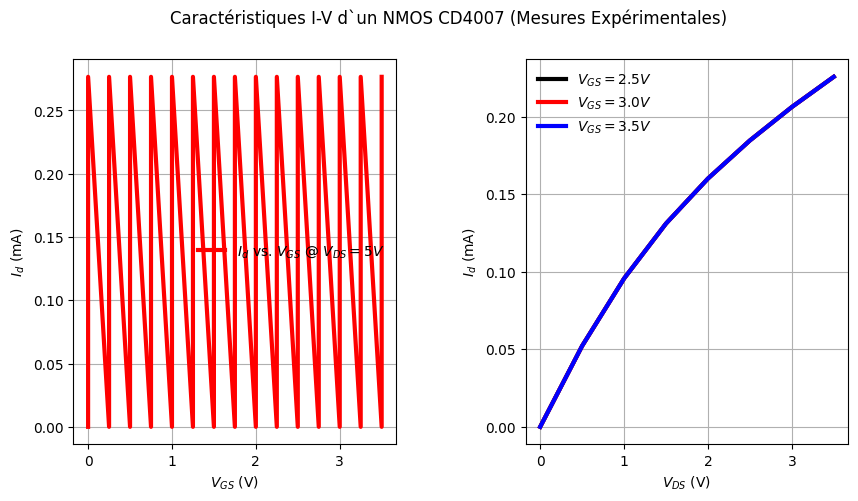

In [9]:
# --- 1. CHARGEMENT Id vs Vgs ---
# Utilise sep=',' car ton script de mesure utilise csv.DictWriter (virgule par défaut)
data_vg = pd.read_csv(path+'\\Test_experimentale\\IdVd_0_cas_1.csv', sep=',')
print(data_vg)
Vgs = data_vg['Gate_Voltage']
Id = data_vg['Drain_Current'] * 1000 

# --- 2. CHARGEMENT Id vs Vds ---
data_vd = pd.read_csv(path+'\\Test_experimentale\\IdVd_1_cas_2.csv', sep=',')
print(data_vd)

# Filtrage par tes vraies valeurs de Vgs
m1 = data_vd['Gate_Voltage'] == 2.5
Vds_1, Id_1 = data_vd['Drain_Voltage'][m1], data_vd['Drain_Current'][m1] * 1000

m2 = data_vd['Gate_Voltage'] == 3.0
Vds_2, Id_2 = data_vd['Drain_Voltage'][m2], data_vd['Drain_Current'][m2] * 1000

m3 = data_vd['Gate_Voltage'] == 3.5
Vds_3, Id_3 = data_vd['Drain_Voltage'][m3], data_vd['Drain_Current'][m3] * 1000

# --- GRAPHIQUES ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('Caractéristiques I-V d`un NMOS CD4007 (Mesures Expérimentales)')

# Id vs Vgs
ax1.plot(Vgs, Id, lw=3, label="$I_d$ vs. $V_{GS}$ @ $V_{DS}=5V$", color="red")
ax1.set_xlabel("$V_{GS}$ (V)")
ax1.set_ylabel("$I_d$ (mA)")
ax1.grid()
ax1.legend(frameon=False)

# Id vs Vds - Mise à jour des labels avec TES valeurs
ax2.plot(Vds_1, Id_1, lw=3, label='$V_{GS} = 2.5 V$', color="black")
ax2.plot(Vds_2, Id_2, lw=3, label='$V_{GS} = 3.0 V$', color="red")
ax2.plot(Vds_3, Id_3, lw=3, label='$V_{GS} = 3.5 V$', color="blue")

ax2.set_xlabel("$V_{DS}$ (V)")
ax2.set_ylabel("$I_d$ (mA)")
ax2.grid()
ax2.legend(frameon=False)

plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

## **C3 - Traitement post-mesures :** 
- Comparez vos résultats de simulations et vos mesures - observez vous des différences majeures
- Determinez les paramétres $k_n$, $V_{tn}$ et eventuellement $\lambda_n$ et comparez les avec ceux extraits de vos simulations 

## **Commentaires**

In [5]:
#mettez vos résultats ici avec les interpretations#

## BONUS - Reproduire pour un PMOS

# **D - CARACTÉRISTIQUES DE TRANSFERT D‘UN TRANSISTOR BJT (BONUS)**  
**Objectifs**: 
- Simuler un transistor BJT [figure 4](#fig4) et étudier l‘évolution du courant collecteur vs. la tension ´emetteur-base et collecteur-´emetteur
- Assembler un circuit et mesurer $I_C$ vs. $V_{BE}$ et $I_C$ vs. $V_{CE}$
- Extraire les paramètres : β, $V_A$

<img src="./PNG_circuits/lab61_NPN.png"
     width="500"
     style="display:block; margin:auto;">
<p style="text-align:center"><strong>Fig. 4</strong>: Transistor BJT</p>

## **D1 - Simulation**:  
Simulez ce circuit en placant 2 alimentations dc sur la base et le collecteur du transistor. Tracez:
- $I_C$ vs. $V_{BE}$: maintenir  $V_{CE}$ constante á 5 V et balayez $V_{BE}$ de 0 á 0.8 V par pas de 0.1 V. Déterminez la tension de seuil.
- Que valent les courants $I_C$ et $I_B$ lorsque  $V_{BE}$ = 0.7 V? calculer β
- $I_C$ vs. $V_{CE}$ : pour 3 valeurs de  $V_{BE}$ (0.6, 0.7 et 0.8 V ajustez pour avoir des tracés résolus), balayez $V_{CE}$ de 0 à 2 V par pas de 0.1 V. 

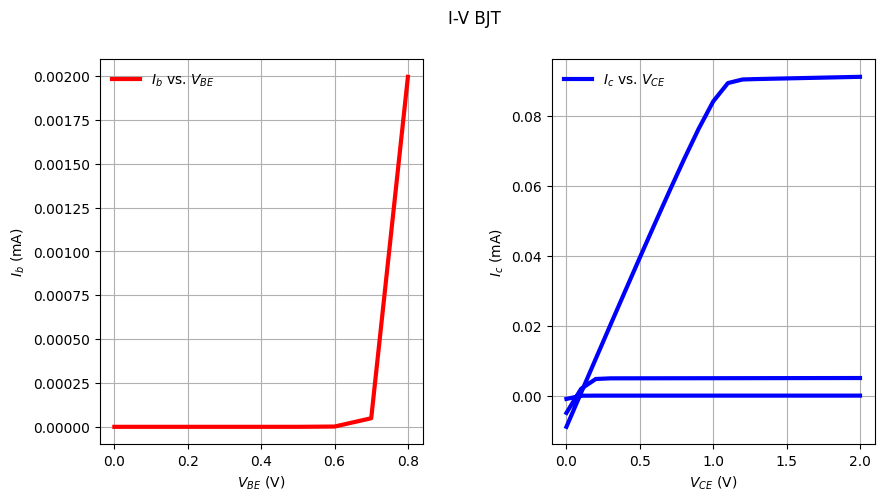

In [10]:
#exporter vos simulations en .txt et tracer les en subplot dans cette cellule
a = pd.read_csv(path+'\\Simulation\\Simu_D\\Simu_D_cas_1.txt',  delimiter = "\t")
# print(a)
b = pd.read_csv(path+'\\Simulation\\Simu_D\\Simu_D_cas_2.txt',  delimiter = "\t")
# NMOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('I-V BJT')
ax1.plot(a["V(vbe)"], a["Ib(Q1)"],  lw=3,label = "$I_b$ vs. $V_{BE}$", color="red")
ax1.set_xlabel("$V_{BE}$ (V)")
ax1.set_ylabel("$I_b$ (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(b["V(vce)"], b["Ic(Q1)"],  lw=3,label = "$I_c$ vs. $V_{CE}$", color="blue")
ax2.set_xlabel("$V_{CE}$ (V)")
ax2.set_ylabel("$I_c$ (mA)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

## **D2 - Mesures**:  
Assemblez le circuit et mesurer:
- $I_b$ vs. $V_{BE}$ : maintenir $V_{CE}$ constante à 5 V et balayez la tension de base de 0 à 0.8 V par pas de 0.1 V en mesurant $I_b$ vs. $V_{BE}$. Tracez la caractétistique et déterminez la tension de seuil $V_{BE}$ pour laquelle le courant augmente exponentiellement.
- Mesurer $I_b$ et $I_c$ pour $V_{BE}$ = 0.7 V et calculer β
- $I_c$ vs. $V_{CE}$ : pour 3 valeurs de $V_{BE}$ (0.6, 0.7 et 0.8 V), balayez $V_{CE}$ de 0 à 1 V par pas de 0.1 V en mesurant $I_c$.

In [ ]:
#IV BJT   mettre des resistances 100k et 1k comme simulation
#Ic vs Vbe
Vce = 5
Vbe =  [vos mesures]  # en V
Ib =   [vos mesures] # en V

#mesure du courant ib et ic
ic_beta = xxx
ib_beta = xxx
beta = ic_beta/ib_beta
print("beta = ", beta) # attention peut varier selon le composant attention à la comparaison avec SPICE

# Ic vs Vce
Vbe_1 = xx
Vbe_2 = xx
vbe_3 = xx
vbe_4 = xx

Vce_1 =  [vos mesures]  # en V
Ic_1 =   [vos mesures] # en V
Vce_2 =  [vos mesures]  # en V
Ic_2=   [vos mesures] # en V
Vce_3 =  [vos mesures]  # en V
Ic_3 =   [vos mesures] # en V
# Vce_4 =  [vos mesures]  # en V
# Ic_4 =   [vos mesures] # en V

#courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('Caractéristiques I-V d`un BJT CA3046')
ax1.plot(Vbe, Ib,  lw=3,label = "$I_b$ vs. $V_{BE}$ @ $V_{CE}$ = 5 V", color="red")
ax1.set_xlabel("$V_{BE}$ (V)")
ax1.set_ylabel("$I_b$ (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(Vce_1,Ic_1,lw=3,label = '$_{Vbe}$ = 0.5 V', color="black")
ax2.plot(Vce_2,Ic_2,lw=3,label = '$_{Vbe}$ = 0.6 V', color="red")
ax2.plot(Vce_3,Ic_3,lw=3,label = '$_{Vbe}$ = 0.7 V', color="blue")
# ax2.plot(Vce_4,Ic_4,lw=3,label = '$_{Vbe}$ = 0.7 V', color="green")
ax2.set_xlabel("$V_{CE}$ (V)")
ax2.set_ylabel("$I_c$ (mA)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)

## **D3 - Traitement post-mesures**:  

- Observez vous des differences entre le modèle simulé et la mesure?
- Est il possible de de déterminer la tension de Early?

## **Commentaires**

In [6]:
#mettez vos résultats ici avec les interpretations#

# **E - AMPLIFICATEUR NMOS SOURCE COMMUNE (CS)**  
**Objectifs**: 
- Analyse DC et petit signal - étude théorique
- Simulation et comparaison avec la préparation
- Assembler le circuit et mesurer les performances de l‘amplificateur - comparaison avec la simulation
- Mesure de la résistance de sortie
- Évaluer qualitativement l‘impact des variations entre transistors

## **E1 - Dimensionnement et simulation**:  
On considère le circuit de la [figure 5](#fig5), on souhaite dimensionner l‘amplificateur pour un gain petit signal $A_v$=-5V/V. On prendra $V_+$ = $V_−$ = 15 V, $R_{sig}$ = 50 $\Omega$, $R_L$ = 10 k$\Omega$, $R_G$ = 10 k$\Omega$ et on concevra le circuit pour un courant $I_D$ = 1 mA.

<img src="./PNG_circuits/lab71_CS.png"
     width="500"
     style="display:block; margin:auto;">
<p style="text-align:center"><strong>Fig. 5</strong>: Circuit amplificateur CS</p>

**Analyse DC et point de fonctionnement**:
- Schématisez un modèle DC: remplacez les capacités de couplages $C_{C1}, C_{C2}, C_{C3}$ par des circuits ouverts (pour simplifier on omettra $v_{sig}, R_{sig}, R_{L}$) - quel est le courant dc traversant $R_G$ ?
- Vous pouvez maintenant déduire $V_{OV}=V_{GS}-V_{tn}$ et la valeur de $g_m$ - que vaut $V_{GS}$. NB: votre transistor a en réalité une valeur de $V_{tn}$ qui varie un peu de sa valeur nominale ce qui affectera vos mesures:
- Calculez $r_o$
- Les calculs précédents vous permettent de déterminer $R_S$. Si cette valeur n'existe pas dans la série de résistance de la salle TP, assemblez plusieurs résistances pour vous en approcher. NB: à ce stade vous n'avez déterminer ni $V_{DS}$ ni $R_D$.

**Résultats intermédiaires**:
mettre dans cette cellule les valeurs calculées - montrez à votre encadrant votre préparation - la tolérance est large sur les valeurs, la démarche est importante.

**Analyse AC**:
- Remplacez le transistor par son modèle petit signal, les capacités sont court circuitées (qu'advient il de $R_S$?) et en remplaçant $V_+$ par une masse (qu'advient il de $V_-$?) - nommez le signal sur la grille du transistor $v_i$ i.e. tension d'entrée petit signal.
- Calculez le rapport $v_i/v_{sig}$ -  comment l'approximer?
- Déduire une expression pour $A_v=v_o/v_i$ - quelle est la valeur de $R_D$ qui produit un gain en tension petit signal $A_v$ d'au moins 5V/V?
- Quelle est la tension dc au drain - satisfait elle à la condition de saturation du transistor - commentez
- Quelle est la résistance de sortie $R_o$

**Résultats intermédiaires**:
mettre dans cette cellule les valeurs calculées - montrez à votre encadrant votre préparation - la tolérance est large sur les valeurs, la démarche est importante.

**Simulation**:
- Simuler le circuit avec $C_{C1}=C_{C2}=C_{S}=47\mu F$ et les valeurs de $R_S$ et $R_D$ déterminées dans les analyses précédentes. Injectez un signal $v_{sig}$ de 10 $mV_{pk-pk}$/1 kHz sans offset dc.
- De vos simulations, relevez les valeurs dc de $V_{GS}, V_{DS}, I_D$ -  comparez à vos calculs.
- Relever $A_v$ - est il proche de vos calculs?

**Résultats de simulation**:
mettre dans cette cellule les valeurs issues de vos simulations - montrer à votre encadrant votre préparation - la tolérance est large sur les valeurs, la démarche est importante.

In [ ]:
a = pd.read_csv(path+'\xxxx.txt',  delimiter = "\t")
fig, (ax1) = plt.subplots(1, 1, figsize=(5,5))
fig.suptitle('Amplificateur CS')
ax1.plot(1000*a["time"], a["V(vo)"],  lw=3,label = "$v_o$", color="red")
ax1.plot(1000*a["time"], a["V(n002)"],  lw=3,label = "$v_i$", color="blue")
ax1.set_xlabel("time (ms)")
ax1.set_ylabel("$v$ (V)")
ax1.grid()
ax1.legend(frameon=False)

## **E2 - Prototypage**:  
Assemblez le circuit sur labdec que vous venez de dimensionner - $R_{sig}$ représente la résistance de sortie de votre générateur de fonction et ne doit donc pas être incluse dans votre circuit

## **E3 - Mesures**:  
- **Mesure du point de fonctionnement**: Mesurez au multimetre les tensions $V_G$, $V_D$ et $V_S$ du transistor
- **Mesure AC**: A l'aide d'un GBF injectez un signal de 10 $mV_{pk-pk}$/1 kHz sans offset dc
- A l'oscilloscope, visualiser $v_o$ et $v_i$ en fonction du temps
- **Résistance de sortie $R_o$**: remplacez $R_L$ par une résistance de 1M$\Omega$ et refaire les mesures ac - Quelle est l'amplitude du signal de sortie. Ajustez $R_L$ pour obtenir une amplitude de 50\% de la valeur précédente. Cette nouvelle valeur de $R_L$ représente votre résistance $R_o$. Comparez la avec celle calculée ($R_o$ ne peut pas être plus grande que $R_D$).
- Qu'advient il du signal de sortie si on augmente le signal d'entrée e.g. 1 $V_{pk-pk}$? - A quelle amplitude commence t-on à observer de fortes distorsions du signal de sortie - expliquez

**Traitement post-mesures**:
- Calculez $V_{GS}$ et $V_{DS}$ obtenues. Comparez avec les calculs et expliquez les différences
- A partir des mesure de $V_D$ et $V_S$, et des résistances du circuits, quelle est la valeur réelle de $I_D$
- Quelle est la valeur de $A_v$ mesurée? comparez à vos calculs et expliquez les différences

## **Commentaires**

In [7]:
#mettez vos résultats ici avec les interpretations#

# **F - NMOS vs. NPN: COMPARAISON AMPLIFICATEUR SOURCE COMMUNE (CS)/ÉMETTEUR COMMUN (CE)**  
**Objectifs**: 
- assembler et comparer les performances d'un amplificateur CS (NMOS) et CE (BJT)
On considère les 2 circuits de la [figure 6](#fig6), remarquer les similarités entre les 2. Le travail effectué pour le CS en partie E demeure valable.

<img src="./PNG_circuits/lab717_comparaison.png"
     width="500"
     style="display:block; margin:auto;">
<p style="text-align:center"><strong>Fig. 6</strong>: Circuits amplificateurs (a) - CS et (b) - CE</p>

## **F1 - Dimensionnement du CE et Mesures**:  

**Dimensionnement**: 
- Nous avons inter changé le NMOS avec un BJT NPN et modifié les notations. On fixe $R_E=R_S$, $R_C=R_D$ et $C_E=C_S$. On maintient les valeurs mesurées pour le CS: $V_E=V_S$ et $I_D=I_E$.
- Quel potentiel $V_B$ est nécessaire sur la base du BJT (NB: un NPN à un $V_{BE}$ de 0.7 V).
- Quelles valeurs de R1 et R2 faut il choisir pour atteindre ce potentiel $V_B$ tout en maintenant R1//R2=10 k$\Omega$? (comme $I_B$$\neq$0, il faut considérer le schéma équivalent de Thevenin)

**Résultats intermédiaires**:
mettre dans cette cellule les valeurs calculées - montrer à votre encadrant votre préparation

## **F2 - Simulation**:
- Simulez le circuit CE en utilisant les calculs précédents. Quel est le gain en tension de ce nouveau circuit? Que valent $V_B, V_C, V_E$? comparez les avec $V_G, V_D, V_S$ du circuit CS

**Résultats de simulation**:
mettre dans cette cellule les valeurs relevées - montrer à votre encadrant votre préparation

In [ ]:
a = pd.read_csv(path+'\xxxxx.txt',  delimiter = "\t")
fig, (ax1) = plt.subplots(1, 1, figsize=(5,5))
fig.suptitle('Amplificateur CS')
ax1.plot(1000*a["time"], a["V(vout)"]*1000,  lw=3,label = "$v_{out}$", color="red")
ax1.plot(1000*a["time"], a["V(vin)"]*1000,  lw=3,label = "$v_{in}$", color="blue")
ax1.set_xlabel("time (ms)")
ax1.set_ylabel("$v$ (mV)")
ax1.grid()
ax1.legend(frameon=False)

## **F3 - Mesures**:
- Assemblez le circuit CE sur labdec avec les composants calculés. Vous ne devriez avoir qu'à inter changer le NMOS avec le BJT et remplacer les nouvelles valeurs de R1 et R2
**Mesures**:
- Avec un multimetre, mesurer les tensions dc du circuit à la base $V_B$, l'émetteur $V_E$ et au collecteur $V_C$ du BJT. Ensuite injectez avec un GBF, un sinus de 50 $mV_{pk-pk}$/1 kHz sans offset dc à l'entrée. A l'oscilloscope relevez: $v_o$ et $v_i$ en fonction de t.
- Déterminer $A_v$

**RESULTATS**

In [ ]:
#Av - EC
vpp_in = xxx
vpp_out = xxxx
Av_EC = vpp_out/vpp_in
#Av - CS
vpp_in_MOS = xxx
vpp_out_MOS = xxxx
Av_CS = vpp_out_MOS/vpp_in_MOS
print("Av_CS = ", Av_CS)
print("Av_EC = ", Av_EC)